In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import requests
import sqlite3

from google.cloud import storage
from google.colab import auth

In [ ]:
#gcp auth
auth.authenticate_user()

client = storage.Client(project="ds2002-492012")
bucket = client.bucket("ds2002-capstone-sp26-v2")

# List files in your team folder
blobs = list(bucket.list_blobs(prefix="team-21/"))
for b in blobs:
    print(b.name)

In [ ]:
# Operators
blob = bucket.blob("team-21/operators_cleaned.csv")
blob.download_to_filename("operators_cleaned.csv")
operators = pd.read_csv("operators_cleaned.csv")

# Sessions
blob = bucket.blob("team-21/sessions_cleaned.csv")
blob.download_to_filename("sessions_cleaned.csv")
sessions = pd.read_csv("sessions_cleaned.csv")

# Stations
blob = bucket.blob("team-21/stations_cleaned.csv")
blob.download_to_filename("stations_cleaned.csv")
stations = pd.read_csv("stations_cleaned.csv")

# Vehicles
blob = bucket.blob("team-21/vehicles_cleaned.csv")
blob.download_to_filename("vehicles_cleaned.csv")
vehicles = pd.read_csv("vehicles_cleaned.csv")

In [ ]:
#db
blob = bucket.blob("team-21/energy_and_demand_cleaned.db")
blob.download_to_filename("energy_and_demand_cleaned.db")

conn = sqlite3.connect("energy_and_demand_cleaned.db")

In [ ]:
#db reading
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)

demand = pd.read_sql("SELECT * FROM daily_demand_summary", conn)
grid = pd.read_sql("SELECT * FROM grid_capacity_levels", conn)

sessions["date"] = pd.to_datetime(sessions["session_start"]).dt.date

daily_ev = sessions.groupby("date").agg({
    "kwh_delivered": "sum",
    "session_id": "count"
}).reset_index()



Weather data: (365, 4)


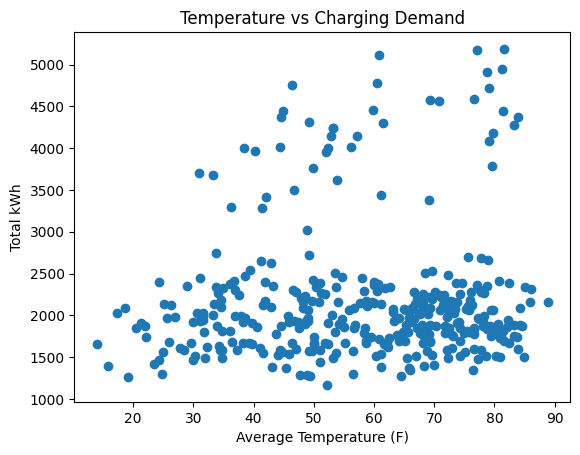

,kwh_delivered,temp_avg,temp_lag1,temp_lag2
kwh_delivered,1.000000,0.090961,0.080387,0.072838
temp_avg,0.090961,1.000000,0.946915,0.899701
temp_lag1,0.080387,0.946915,1.000000,0.946633
temp_lag2,0.072838,0.899701,0.946633,1.000000


In [ ]:
# Charlottesville coordinates: 38.03, -78.48
# Example: get daily temperature for January 2025
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 38.03,
    "longitude": -78.48,
    "start_date": "2025-01-01",
    "end_date": "2025-12-31",
    "daily": "temperature_2m_max,temperature_2m_min,precipitation_sum",
    "timezone": "America/New_York"
}

resp = requests.get(url, params=params)
data = resp.json()

weather = pd.DataFrame({
    "date": data["daily"]["time"],
    "temp_max_f": [c * 9/5 + 32 for c in data["daily"]["temperature_2m_max"]],
    "temp_min_f": [c * 9/5 + 32 for c in data["daily"]["temperature_2m_min"]],
    "precip_mm": data["daily"]["precipitation_sum"]
})

# NOW convert date (after creating the DataFrame)
weather["date"] = pd.to_datetime(weather["date"]).dt.date

print(f"Weather data: {weather.shape}")
weather.head()

daily_ev = sessions.groupby("date").agg({
    "kwh_delivered": "sum",
    "session_id": "count"
}).reset_index()
merged = daily_ev.merge(weather, on="date", how="inner")

merged.shape
merged.head()

merged["temp_avg"] = (merged["temp_max_f"] + merged["temp_min_f"]) / 2

# extreme weather flags
merged["is_hot"] = merged["temp_max_f"] > 90
merged["is_cold"] = merged["temp_min_f"] < 32


plt.scatter(merged["temp_avg"], merged["kwh_delivered"])
plt.xlabel("Average Temperature (F)")
plt.ylabel("Total kWh")
plt.title("Temperature vs Charging Demand")
plt.show()

merged["temp_lag1"] = merged["temp_avg"].shift(1)
merged["temp_lag2"] = merged["temp_avg"].shift(2)

merged[["kwh_delivered", "temp_avg", "temp_lag1", "temp_lag2"]].corr()

In [ ]:
sessions.columns

Index(['session_id', 'station_id', 'vehicle_id', 'session_start',
       'session_end', 'kwh_delivered', 'session_type', 'cost_usd',
       'payment_method', 'connector_used', 'user_id', 'date'],
      dtype='object')

In [ ]:
#Q1: Demand Surge Identification
#Which time periods experienced the greatest charging demand surges compared to the baseline? Quantify the percentage increase in daily sessions and total kWh delivered for each surge period, and visualize the daily trend across the full year.

sessions["date"] = pd.to_datetime(sessions["session_start"]).dt.date

daily = sessions.groupby("date").agg({
    "session_id": "count",
    "kwh_delivered": "sum"
}).reset_index()

daily.rename(columns={
    "session_id": "sessions"
}, inplace=True)


daily["baseline_sessions"] = daily["sessions"].rolling(window=14, min_periods=7).mean()
daily["baseline_kwh"] = daily["kwh_delivered"].rolling(window=14, min_periods=7).mean()

daily["session_change_pct"] = (
    (daily["sessions"] - daily["baseline_sessions"]) /
    daily["baseline_sessions"]
) * 100

daily["kwh_change_pct"] = (
    (daily["kwh_delivered"] - daily["baseline_kwh"]) /
    daily["baseline_kwh"]
) * 100

surges = daily[daily["session_change_pct"] > 25]

surges = daily[
    (daily["session_change_pct"] > 25) |
    (daily["kwh_change_pct"] > 25)
]

surges[["session_change_pct", "kwh_change_pct"]].mean()
surges.sort_values("session_change_pct", ascending=False).head(10)


,date,sessions,kwh_delivered,baseline_sessions,baseline_kwh,session_change_pct,kwh_change_pct
318,2025-11-15,150,5111.17,66.357143,2176.087857,126.049516,134.878844
67,2025-03-09,144,4451.05,67.000000,2207.880000,114.925373,101.598366
311,2025-11-08,141,4780.28,67.142857,2171.080000,110.000000,120.179818
290,2025-10-18,143,4454.65,68.785714,2280.989286,107.892004,95.294648
248,2025-09-06,140,4911.90,67.785714,2263.569286,106.533193,116.997997
353,2025-12-20,137,4008.04,67.000000,2127.992143,104.477612,88.348440
262,2025-09-20,144,4566.56,71.142857,2276.495000,102.409639,100.596092
304,2025-11-01,137,4149.55,67.857143,2202.732857,101.894737,88.381900
269,2025-09-27,147,4578.43,73.214286,2379.674286,100.780488,92.397339
195,2025-07-15,130,3783.42,64.857143,2017.125000,100.440529,87.564975


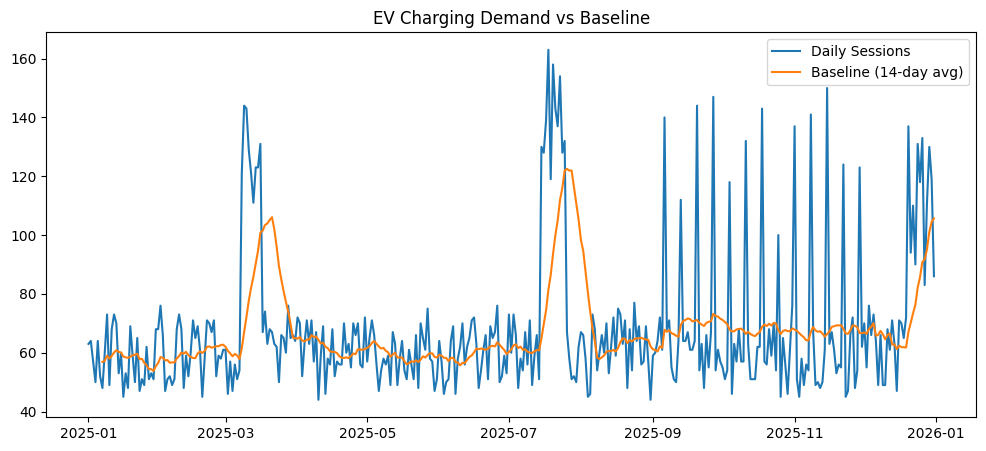

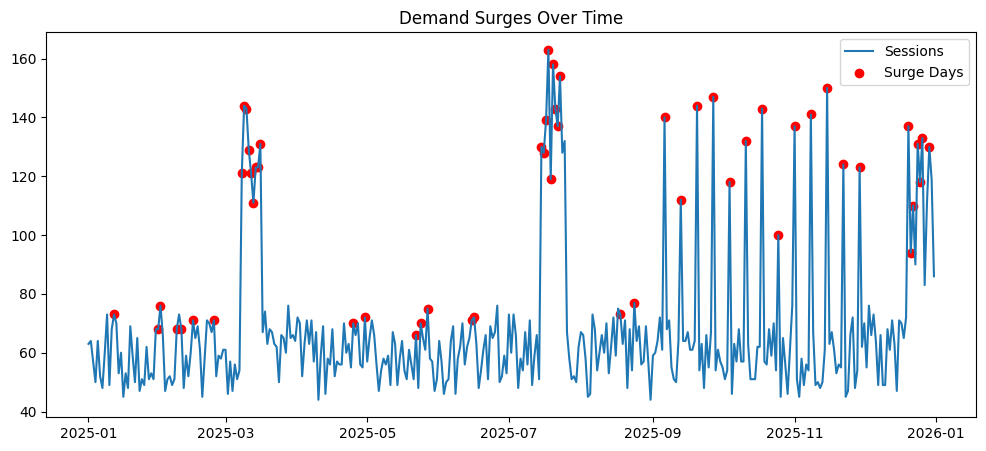

In [ ]:
#full year trend
plt.figure(figsize=(12,5))
plt.plot(daily["date"], daily["sessions"], label="Daily Sessions")
plt.plot(daily["date"], daily["baseline_sessions"], label="Baseline (14-day avg)")
plt.legend()
plt.title("EV Charging Demand vs Baseline")
plt.show()

#surges
plt.figure(figsize=(12,5))
plt.plot(daily["date"], daily["sessions"], label="Sessions")

plt.scatter(
    surges["date"],
    surges["sessions"],
    color="red",
    label="Surge Days"
)
plt.legend()
plt.title("Demand Surges Over Time")
plt.show()

The demand in Charlottesville is not uniform. Our baseline is steady, staying 60 and 70 sessions per day, while the "surge" events double that volume often. These 100%+ increases suggest that  Charlottesvielle needs to ensure transformers can handle "peak-on-peak" situtations, especially during the November cluster where multiple surge days occur back to back.



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

q2 = sessions.copy()
q2["date"] = pd.to_datetime(q2["session_start"]).dt.date

vehicles_clean = vehicles[["vehicle_id_clean", "vehicle_name"]].drop_duplicates()

q2 = q2.merge(
    vehicles_clean,
    left_on="vehicle_id",
    right_on="vehicle_id_clean",
    how="left"
)

q2["vehicle_fragmented"] = q2["vehicle_id"]
q2["vehicle_consolidated"] = q2["vehicle_name"].fillna(q2["vehicle_id"])

frag_counts = q2.groupby("vehicle_fragmented").agg(
    session_count=("session_id", "count"),
    total_kwh=("kwh_delivered", "sum")
).reset_index().sort_values("session_count", ascending=False)

cons_counts = q2.groupby("vehicle_consolidated").agg(
    session_count=("session_id", "count"),
    total_kwh=("kwh_delivered", "sum")
).reset_index().sort_values("session_count", ascending=False)

top5 = cons_counts.head(5)["vehicle_consolidated"].tolist()

daily_top5 = q2[q2["vehicle_consolidated"].isin(top5)].groupby(
    ["date", "vehicle_consolidated"]
).agg(
    daily_sessions=("session_id", "count"),
    daily_kwh=("kwh_delivered", "sum")
).reset_index()

pivot_sessions = daily_top5.pivot(index="date", columns="vehicle_consolidated", values="daily_sessions").fillna(0)
pivot_kwh = daily_top5.pivot(index="date", columns="vehicle_consolidated", values="daily_kwh").fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(
    frag_counts.head(10)["vehicle_fragmented"][::-1],
    frag_counts.head(10)["session_count"][::-1]
)

axes[1].barh(
    cons_counts.head(10)["vehicle_consolidated"][::-1],
    cons_counts.head(10)["session_count"][::-1]
)

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
for col in pivot_sessions.columns:
    plt.plot(pivot_sessions.index, pivot_sessions[col], label=col)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
for col in pivot_kwh.columns:
    plt.plot(pivot_kwh.index, pivot_kwh[col], label=col)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The fragmented vehicle labels use internal IDs (e.g., VH-001), while the consolidated labels map these IDs to actual vehicle models (e.g., TESLA MODEL 3, CHEVROLET BOLT EV). The number of unique labels remains the same (14), indicating there was no true fragmentation in the dataset, only a difference in representation. This shows the data was already well-structured, and consolidation mainly improved interpretability rather than reducing redundancy.

In [ ]:
# Q3

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

def pick_col(df, candidates):
    cols_lower = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    for cand in candidates:
        for c in df.columns:
            if cand.lower() in c.lower():
                return c
    return None

sessions_q3 = sessions.copy()
grid_q3 = grid.copy()

sess_date_col = pick_col(sessions_q3, ["date", "session_start"])
sess_session_id_col = pick_col(sessions_q3, ["session_id", "id"])
sess_kwh_col = pick_col(sessions_q3, ["kwh", "energy"])

sessions_q3["date"] = pd.to_datetime(sessions_q3[sess_date_col]).dt.date

daily_ev = sessions_q3.groupby("date").agg(
    daily_sessions=(sess_session_id_col, "count"),
    daily_kwh=(sess_kwh_col, "sum")
).reset_index()

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 38.03,
    "longitude": -78.48,
    "start_date": "2025-01-01",
    "end_date": "2025-12-31",
    "daily": "temperature_2m_max,temperature_2m_min,precipitation_sum",
    "timezone": "America/New_York"
}

resp = requests.get(url, params=params)
data = resp.json()

weather_q3 = pd.DataFrame({
    "date": pd.to_datetime(data["daily"]["time"]).date,
    "temp_max_f": [x * 9/5 + 32 for x in data["daily"]["temperature_2m_max"]],
    "temp_min_f": [x * 9/5 + 32 for x in data["daily"]["temperature_2m_min"]],
    "precip_mm": data["daily"]["precipitation_sum"]
})

weather_q3["temp_avg"] = (weather_q3["temp_max_f"] + weather_q3["temp_min_f"]) / 2

merged = daily_ev.merge(weather_q3, on="date", how="inner")

display(merged[["temp_avg", "daily_sessions", "daily_kwh"]].corr())

plt.figure()
plt.scatter(merged["temp_avg"], merged["daily_sessions"])
plt.show()

plt.figure()
plt.scatter(merged["temp_avg"], merged["daily_kwh"])
plt.show()

grid_date_col = pick_col(grid_q3, ["date", "timestamp"])
grid_operator_col = pick_col(grid_q3, ["operator", "utility"])
grid_load_col = pick_col(grid_q3, ["load", "demand"])

grid_q3[grid_date_col] = pd.to_datetime(grid_q3[grid_date_col])
grid_q3["month"] = grid_q3[grid_date_col].dt.strftime("%b")

heatmap_df = grid_q3.groupby(
    [grid_operator_col, "month"]
)[grid_load_col].mean().reset_index().pivot(
    index=grid_operator_col,
    columns="month",
    values=grid_load_col
)

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_df, annot=True)
plt.show()

The correlation matrix shows that average temperature has only a very weak positive relationship with both daily charging sessions (0.077) and daily kWh delivered (0.091). This suggests weather is not a major driver of EV charging demand in this dataset. In contrast, daily sessions and daily kWh have a very strong positive correlation (0.975), indicating that total charging volume is primarily driven by the number of charging events.

# Q4: Station-Level Geographic Patterns